
# Giải thích bài báo **LIMOncello** từ con số 0  
## Notebook cho người chưa biết gì về robotics, LiDAR, IMU, Kalman filter, hay manifold

**Mục tiêu của notebook này**

Notebook này giải thích bài báo:

> **Carlos Perez-Ruiz, Joan Solà**  
> *LIMOncello: Iterated Error-State Kalman Filter on the SGal(3) Manifold for Fast LiDAR–Inertial Odometry*  
> arXiv:2512.19567v2, 2026.

Mình viết theo hướng **rất dễ hiểu**, ưu tiên **trực giác trước**, **toán sau**.  
Bạn **không cần biết trước** robotics, 3D vision, hay lý thuyết Lie.

---

## Notebook này có gì?

1. Giải thích **SLAM**, **odometry**, **LiDAR**, **IMU**, **point cloud**.
2. Giải thích vì sao quét LiDAR bị **méo do chuyển động** và vì sao cần **deskewing**.
3. Giải thích **Kalman Filter**, **EKF**, **ESKF**, **IESKF** bằng ngôn ngữ đơn giản.
4. Giải thích **manifold**, **tangent space**, **Lie group**, **Lie algebra**, **Exp/Log**, **⊕ / ⊖**.
5. Giải thích các không gian quan trọng trong bài: **SO(3)**, **SE(3)**, **S²**, **SGal(3)**.
6. Giải thích pipeline của **LIMOncello** từng bước.
7. Giải thích phần **mapping bằng i-Octree** và so sánh với **ikd-Tree**.
8. Tóm tắt **kết quả thực nghiệm**, **điểm mạnh**, **điểm yếu**, và **tài liệu đọc tiếp**.

---

## Cách dùng notebook

- Nếu bạn mới hoàn toàn, hãy đọc **theo thứ tự từ trên xuống**.
- Nếu bạn chỉ muốn hiểu nhanh bài báo, đọc các phần:
  - **Bức tranh lớn**
  - **Ý tưởng mới của LIMOncello**
  - **Pipeline**
  - **Kết quả**
- Nếu bạn thấy toán khó, đừng lo. Trong notebook này, mỗi công thức đều có phần **dịch sang tiếng người**.

---

## Ý chính quan trọng nhất của bài báo chỉ trong 5 câu

1. Robot muốn biết mình đang ở đâu và đang di chuyển thế nào.
2. **IMU** cho tín hiệu rất nhanh nhưng dễ trôi; **LiDAR** cho hình học môi trường tốt hơn nhưng xử lý nặng.
3. Kết hợp hai cảm biến này tạo thành **LiDAR–Inertial Odometry (LIO)**.
4. Bài báo đề xuất dùng một không gian trạng thái tên là **SGal(3)** thay vì cách ghép quen thuộc kiểu **SO(3) × R⁶**, để mô hình hóa chuyển động gắn kết hơn.
5. Kết quả cho thấy cách làm này đặc biệt hữu ích trong môi trường **hình học nghèo / suy biến** như đường hầm, đồng thời backend map **i-Octree** giúp chạy nhanh và tiết kiệm bộ nhớ hơn.

> **Ghi nhớ:** bài báo này không chỉ là “đổi ký hiệu toán”.  
> Cốt lõi là: **biểu diễn trạng thái tốt hơn + cập nhật LiDAR/IMU chặt hơn + cấu trúc map nhẹ hơn**.



# 1. Bức tranh lớn: robot đang cố làm gì?

Hãy tưởng tượng một robot hoặc xe tự hành đi trong thế giới thật.

Nó cần trả lời ít nhất 2 câu hỏi:

1. **Tôi đang ở đâu?**
2. **Thế giới xung quanh tôi trông như thế nào?**

Hai bài toán này gắn chặt với nhau:

- Muốn xây bản đồ tốt, robot phải biết mình đang ở đâu.
- Muốn biết mình đang ở đâu, robot cần bám vào các mốc trong bản đồ.

Đó chính là tinh thần của **SLAM**:

> **SLAM = Simultaneous Localization and Mapping**  
> = đồng thời **định vị** và **lập bản đồ**.

Trong bài báo này, tác giả tập trung vào một phần rất quan trọng của SLAM là:

> **Odometry** = ước lượng chuyển động tương đối theo thời gian.

Nói đơn giản:

- Ở thời điểm trước robot ở đâu,
- bây giờ robot đã **xoay bao nhiêu**, **dịch bao nhiêu**, **đi nhanh thế nào**.

Nếu odometry tốt, robot sẽ “đi đúng hướng” lâu hơn. Nếu odometry tệ, robot sẽ bị **drift** (trôi dần khỏi quỹ đạo thật).

---

## LIO là gì?

**LIO = LiDAR–Inertial Odometry**

Nó kết hợp:

- **LiDAR**: cảm biến laser quét ra các điểm 3D của môi trường.
- **IMU**: cảm biến quán tính đo gia tốc và vận tốc góc với tần số cao.

Trực giác:

- **IMU** giống như một “đồng hồ chuyển động” rất nhanh: nó biết robot đang rung, quay, tăng tốc.
- **LiDAR** giống như “mắt đo khoảng cách 3D”: nó cho hình học môi trường.

Từng cảm biến riêng lẻ đều có nhược điểm:

### Chỉ dùng IMU
- rất nhanh,
- nhưng khi tích phân theo thời gian, sai số tích lũy rất nhanh,
- nên vị trí và hướng sẽ bị trôi.

### Chỉ dùng LiDAR
- giàu thông tin hình học,
- nhưng tính toán nặng,
- mỗi scan không phải là một ảnh chụp tức thời hoàn toàn,
- và ở nơi ít đặc trưng hình học thì khó xác định chuyển động.

Kết hợp hai cái với nhau giúp:
- IMU lấp khoảng trống thời gian giữa các scan LiDAR,
- LiDAR kéo lại drift của IMU.

Đó là lý do LIO rất mạnh trong robotics hiện đại.



# 2. Các khái niệm nền tảng bạn cần biết trước khi vào bài

## 2.1 LiDAR là gì?

**LiDAR** bắn tia laser ra môi trường và đo thời gian tia phản xạ quay lại, từ đó suy ra khoảng cách.

Kết quả thu được là rất nhiều điểm 3D:

- mỗi điểm là một vị trí trong không gian,
- toàn bộ tập điểm gọi là **point cloud**.

Bạn có thể hình dung point cloud như “đám bụi điểm” mô tả tường, sàn, cột, xe, cây, v.v.

---

## 2.2 IMU là gì?

**IMU = Inertial Measurement Unit**

IMU thường có 2 loại đo chính:

- **Gyroscope**: đo vận tốc góc \( \omega \)  
  → robot đang quay nhanh thế nào.
- **Accelerometer**: đo gia tốc \( a \)  
  → robot đang thay đổi vận tốc thế nào.

IMU có tần số rất cao, ví dụ vài trăm Hz, nên rất hữu ích để theo dõi chuyển động mượt giữa các scan LiDAR.

---

## 2.3 Pose là gì?

**Pose** của robot trong 3D thường gồm:

- **rotation**: robot quay theo hướng nào,
- **translation/position**: robot nằm ở đâu.

Nếu cộng thêm **velocity** thì ta biết robot đang đi nhanh cỡ nào và hướng nào.

---

## 2.4 Point cloud registration là gì?

Khi robot quét LiDAR ở các thời điểm khác nhau, nó thu được nhiều point cloud.

Ta muốn “chồng” các cloud này khớp nhau để biết robot đã di chuyển thế nào.

Việc này gọi là **registration**.

Một cách rất phổ biến là:
1. với mỗi điểm mới, tìm **các điểm lân cận gần nhất** trong bản đồ,
2. từ các láng giềng đó, nội suy ra một cấu trúc đơn giản như **mặt phẳng** hoặc **đường thẳng**,
3. đo xem điểm mới lệch bao xa khỏi cấu trúc đó,
4. điều chỉnh pose của robot để giảm tổng sai lệch.

---

## 2.5 k-NN là gì?

**k-NN = k nearest neighbors**

Nghĩa là:
- với một điểm cần xét,
- tìm ra \(k\) điểm gần nhất trong map.

Ví dụ:
- \(k = 5\) nghĩa là lấy 5 láng giềng gần nhất.

Từ các điểm này, ta có thể:
- ước lượng mặt phẳng cục bộ,
- ước lượng cạnh,
- hoặc dùng trực tiếp cho registration.

---

## 2.6 Residual là gì?

**Residual** là sai số giữa:

- điều mô hình dự đoán,
- và điều dữ liệu thực tế cho thấy.

Trong bài này residual quan trọng nhất là **point-to-plane residual**:

> một điểm sau khi biến đổi theo pose hiện tại còn cách mặt phẳng cục bộ bao xa?

Residual càng nhỏ → pose càng hợp lý.

---

## 2.7 Drift là gì?

**Drift** là sai số tích lũy theo thời gian.

Ví dụ:
- mỗi bước chỉ sai rất ít,
- nhưng sau hàng ngàn bước, robot có thể lệch hàng mét hoặc hơn.

Odometry tốt là odometry drift chậm.

---

## 2.8 “Feature-degenerate” hay “low observability” nghĩa là gì?

Đây là ý rất quan trọng trong bài báo.

### Feature-degenerate environment
Là môi trường có hình học nghèo, khó phân biệt, ví dụ:
- hành lang dài,
- đường hầm,
- bức tường dài phẳng,
- vùng ít cấu trúc 3D.

Trong những nơi như vậy, LiDAR khó “nhìn ra” robot đã chuyển động theo một số hướng nào đó bao nhiêu.

### Low observability
**Observability** = mức độ mà dữ liệu cảm biến cho phép ta suy ra trạng thái thật.

Nếu observability thấp:
- dữ liệu không đủ ràng buộc,
- nhiều chuyển động khác nhau có thể giải thích dữ liệu gần như giống nhau,
- thuật toán dễ drift hoặc diverge.

Đây chính là nơi tác giả cho rằng **SGal(3)** có thể giúp ích.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["font.size"] = 11


Matplotlib is building the font cache; this may take a moment.



# 3. Vì sao bài này phải dùng **manifold** thay vì cộng trừ vector đơn giản?

Đây là chỗ nhiều người mới học robotics hay thấy “khó” nhất, nhưng trực giác lại khá đơn giản.

## 3.1 Nếu trạng thái là vị trí 1D
Ví dụ robot nằm trên trục số:

- vị trí hiện tại: \(x = 10\)
- dịch thêm \(+2\)
- vị trí mới: \(12\)

Ở đây cộng số bình thường là ổn, vì vị trí 1D sống trong không gian Euclid.

---

## 3.2 Nhưng hướng quay không cư xử như vậy

Ví dụ một góc quay trên vòng tròn:

- \(359^\circ + 5^\circ = 364^\circ\)

Nhưng về mặt hình học, \(364^\circ\) chính là \(4^\circ\).

Tức là không gian các hướng quay **không phải** một đường thẳng vô hạn bình thường. Nó có cấu trúc cong / tuần hoàn.

Trong 3D, chuyện còn khó hơn nhiều:
- rotation không thể biểu diễn tốt chỉ bằng cộng trừ tọa độ thường,
- nếu làm sai, bạn dễ tạo ra ma trận không còn là rotation hợp lệ,
- và việc tuyến tính hóa sẽ trở nên kém ổn định.

Đó là lý do người ta dùng **manifold** để mô tả các đại lượng như rotation.


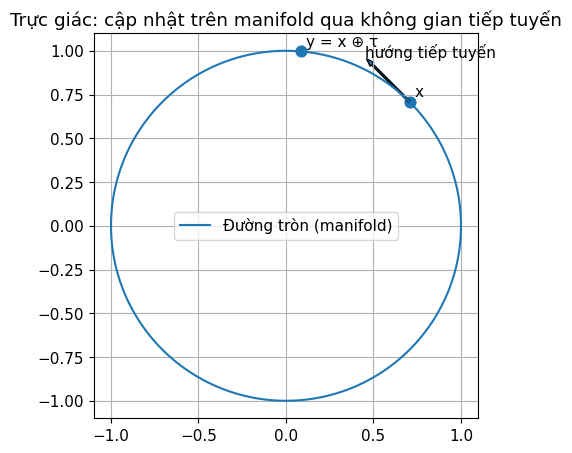

In [2]:

# Ví dụ 2D rất đơn giản để trực giác về manifold:
# Một điểm nằm trên đường tròn đơn vị. Ta không "cộng tọa độ bừa bãi",
# mà cập nhật theo một lượng nhỏ trong không gian tiếp tuyến.

theta0 = np.pi / 4   # góc ban đầu
tau = 0.7            # increment nhỏ trong tangent space

x = np.array([np.cos(theta0), np.sin(theta0)])
y = np.array([np.cos(theta0 + tau), np.sin(theta0 + tau)])
tangent = np.array([-np.sin(theta0), np.cos(theta0)])  # tiếp tuyến tại x

t = np.linspace(0, 2*np.pi, 400)
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(np.cos(t), np.sin(t), label="Đường tròn (manifold)")
ax.scatter([x[0], y[0]], [x[1], y[1]], s=60)
ax.arrow(x[0], x[1], 0.35*tangent[0], 0.35*tangent[1],
         width=0.01, length_includes_head=True)

ax.text(x[0] + 0.03, x[1] + 0.03, "x")
ax.text(y[0] + 0.03, y[1] + 0.03, "y = x ⊕ τ")
ax.text(x[0] + 0.36*tangent[0], x[1] + 0.36*tangent[1], "hướng tiếp tuyến")

ax.set_aspect("equal")
ax.set_title("Trực giác: cập nhật trên manifold qua không gian tiếp tuyến")
ax.legend()
ax.grid(True)
plt.show()



## 3.3 Manifold là gì, nói thật đơn giản?

**Manifold** là một không gian mà:

- nhìn **cục bộ** quanh mỗi điểm, nó trông giống không gian phẳng thông thường,
- nhưng nhìn **toàn cục**, nó có thể cong hoặc có cấu trúc đặc biệt.

Ví dụ kinh điển:
- bề mặt Trái Đất là một manifold 2D,
- đứng trong một vùng nhỏ, ta có thể xem nó gần như phẳng,
- nhưng toàn bộ Trái Đất thì cong.

Trong robotics, các trạng thái như rotation 3D cũng hoạt động kiểu đó.

---

## 3.4 Tangent space là gì?

Tại mỗi điểm trên manifold, ta có một **không gian tiếp tuyến** (**tangent space**).

Đây là nơi:
- ta có thể dùng cộng trừ tuyến tính bình thường,
- biểu diễn các “nhiễu nhỏ”, “sai số nhỏ”, “increment nhỏ”.

Tư duy chuẩn là:

- **state thật** sống trên manifold,
- **sai số nhỏ quanh state** sống trong tangent space.

Đó chính là lý do các bộ lọc kiểu **Error-State Kalman Filter** rất hợp với manifold.

---

## 3.5 Lie group là gì?

Một **Lie group** là một manifold có thêm cấu trúc “nhóm”:
- có phép kết hợp,
- có phần tử đơn vị,
- có phần tử nghịch đảo,
- và mọi thứ trơn đủ để làm giải tích.

Trong robotics, rất nhiều đối tượng quan trọng là Lie group:

- **SO(3)**: nhóm rotation 3D
- **SE(3)**: nhóm pose 3D (rotation + translation)
- **SGal(3)**: nhóm Galilean đặc biệt mà bài này dùng

---

## 3.6 Lie algebra là gì?

Nếu Lie group là “không gian trạng thái cong”,
thì **Lie algebra** là phiên bản tuyến tính cục bộ của nó quanh phần tử đơn vị.

Ta thường:
- tối ưu, cộng nhiễu, làm linearization trong Lie algebra / tangent space,
- rồi dùng hàm mũ để quay lại manifold.

---

## 3.7 Exp và Log là gì?

Không phải logarit / mũ theo nghĩa phổ thông thông thường, mà là:

- **Exp**: đưa một increment nhỏ trong tangent space lên manifold
- **Log**: kéo một phần tử trên manifold về tangent space

Cặp này giúp ta đi qua đi lại giữa:
- thế giới “cong nhưng đúng hình học”,
- và thế giới “phẳng dễ tính toán”.

---

## 3.8 Toán tử \( \oplus \) và \( \ominus \)

Trong bài báo, tác giả dùng:

\[
Y = X \oplus \tau
\]

nghĩa là:
- đang ở trạng thái \(X\) trên manifold,
- áp một increment nhỏ \( \tau \) từ tangent space,
- thu được trạng thái mới \(Y\).

Còn:

\[
\tau = Y \ominus X
\]

nghĩa là:
- lấy chênh lệch giữa hai trạng thái manifold,
- biểu diễn nó thành một vector nhỏ trong tangent space.

> **Dịch rất đời thường:**  
> \( \oplus \) = “cập nhật trạng thái đúng hình học”  
> \( \ominus \) = “đổi chênh lệch hình học thành sai số vector nhỏ”.



# 4. Các không gian / manifold xuất hiện trong bài

Bài báo nhắc tới nhiều không gian toán học. Bạn không cần thuộc định nghĩa trừu tượng; chỉ cần hiểu **mỗi không gian dùng để chứa loại đại lượng nào**.

| Không gian | Chứa cái gì? | Trực giác |
|---|---|---|
| \( \mathbb{R}^n \) | vector thường | vị trí, bias, tham số thường |
| \( SO(3) \) | rotation 3D | robot quay thế nào |
| \( SE(3) \) | pose 3D | quay + tịnh tiến |
| \( S^2 \) | mặt cầu 2 chiều nhúng trong 3D | hướng có độ lớn cố định, ví dụ gravity |
| \( SE_2(3) \) | pose + velocity (một mở rộng quen thuộc trong filtering) | gắn pose và velocity lại với nhau |
| \( SGal(3) \) | rotation + velocity + position + time | mô hình hóa chuyển động 6-DoF có ghép với thời gian |

---

## 4.1 SO(3)

\(SO(3)\) là không gian của mọi rotation 3D hợp lệ.

Nếu bạn lưu rotation bằng ma trận quay \(R\), thì:
- \(R^\top R = I\)
- \(\det(R) = 1\)

Nếu cập nhật rotation không cẩn thận bằng cộng trừ ma trận thường, bạn rất dễ tạo ra một ma trận không còn thỏa điều kiện này. Vì vậy người ta dùng cấu trúc manifold / Lie group.

---

## 4.2 SE(3)

\(SE(3)\) là không gian pose 3D:
- một rotation \(R\),
- và một translation \(p\).

Đây là không gian rất phổ biến trong SLAM.

---

## 4.3 S²

\(S^2\) là mặt cầu trong 3D.

Tại sao gravity lại hay đặt trên \(S^2\)?
Vì:
- **độ lớn** của trọng lực gần như cố định,
- thứ ta cần ước lượng chủ yếu là **hướng** của nó.

Nếu biểu diễn gravity như một vector 3D tự do trong \( \mathbb{R}^3 \), độ lớn của nó có thể trôi lung tung.  
Đặt nó trên \(S^2\) giúp giữ ràng buộc độ lớn cố định một cách tự nhiên hơn.

---

## 4.4 SGal(3): nhân vật chính của bài báo

Đây là điểm mới lớn nhất.

Tác giả dùng trạng thái dạng:

\[
\Gamma =
\begin{bmatrix}
R & v & p \\
0 & 1 & t \\
0 & 0 & 1
\end{bmatrix}
\in SGal(3)
\]

Trong đó:

- \(R\): rotation
- \(v\): velocity
- \(p\): position
- \(t\): time

**Ý tưởng trực giác:**
thay vì giữ rotation, velocity, position như các “mảnh rời” rồi ghép bằng tay,
ta đặt chúng trong một cấu trúc hình học thống nhất hơn.

Theo bài báo, điều này cho một mô hình propagation rời rạc:
- **gắn kết hơn**,
- **ổn định số hơn**,
- hữu ích khi LiDAR bị yếu ràng buộc hình học.

---

## 4.5 Vì sao SGal(3) có thể tốt hơn \(SO(3)\times \mathbb{R}^6\)?

Nhiều hệ LIO cổ điển dùng:
- rotation nằm trên \(SO(3)\),
- velocity và position nằm trong \(\mathbb{R}^3\) riêng rẽ.

Cách này dễ triển khai, nhưng theo tác giả:
- nó bỏ qua một phần ghép nối hình học / động học giữa tịnh tiến và quay,
- nên trong điều kiện động khó hoặc observability thấp, nó có thể kém chính xác / kém ổn định hơn.

Tóm lại:

- **biểu diễn cũ**: dễ làm, phổ biến
- **biểu diễn SGal(3)**: gắn kết motion model tốt hơn



# 5. Kalman Filter → EKF → ESKF → IESKF, hiểu từ gốc

## 5.1 Kalman Filter cổ điển

Kalman Filter giải bài toán:

- ta có một trạng thái ẩn \(x\),
- nó thay đổi theo thời gian,
- ta có mô hình dự đoán và các phép đo nhiễu,
- ta muốn ước lượng trạng thái tốt nhất.

Nó có 2 pha:

### Predict
Dùng mô hình động lực học để đẩy trạng thái tiến lên theo thời gian.

### Update
Dùng đo đạc mới để sửa lại trạng thái.

Trực giác:
- predict giống như “đi theo quán tính”
- update giống như “nghe cảm biến kéo lại”

---

## 5.2 EKF là gì?

**EKF = Extended Kalman Filter**

Khi hệ không tuyến tính, EKF sẽ:
- tuyến tính hóa quanh trạng thái hiện tại,
- rồi áp dụng ý tưởng Kalman tương tự.

Rất nhiều bài toán robotics là không tuyến tính, nên EKF cực kỳ phổ biến.

---

## 5.3 ESKF là gì?

**ESKF = Error-State Kalman Filter**

Đây là biến thể rất quan trọng.

Thay vì filter trực tiếp trên state “to”,
ta tách thành:

- **nominal state**: trạng thái chính trên manifold
- **error state**: sai số nhỏ, tuyến tính được

Ý tưởng:
- nominal state được tích phân bằng mô hình phi tuyến “đúng hình học”,
- error state đủ nhỏ để Kalman filter xử lý tốt.

Đặc biệt phù hợp với:
- rotation,
- pose,
- manifold.

---

## 5.4 IESKF là gì?

**IESKF = Iterated Error-State Kalman Filter**

Chữ **Iterated** nghĩa là:
- không update một lần rồi thôi,
- mà lặp lại update vài vòng trên cùng dữ liệu LiDAR,
- để xử lý phi tuyến tốt hơn.

Trực giác:
- update đầu tiên kéo trạng thái đến gần đúng hơn,
- rồi ta tuyến tính hóa lại tại điểm tốt hơn,
- làm tiếp cho đến khi hội tụ hoặc đạt số vòng lặp tối đa.

---

## 5.5 “on manifolds” nghĩa là gì?

Trong bài báo, bộ lọc không chạy trên vector Euclid đơn giản,
mà chạy với state sống trên manifold.

Điều này buộc ta phải:
- định nghĩa đúng cách state được cập nhật thế nào,
- định nghĩa sai số nhỏ nằm ở đâu,
- vận chuyển covariance thế nào giữa các tangent space.

Đó là lý do bài báo dành hẳn phần Preliminaries cho:
- manifold,
- \( \oplus / \ominus \),
- Jacobian trên manifold,
- Lie group,
- S²,
- SGal(3).


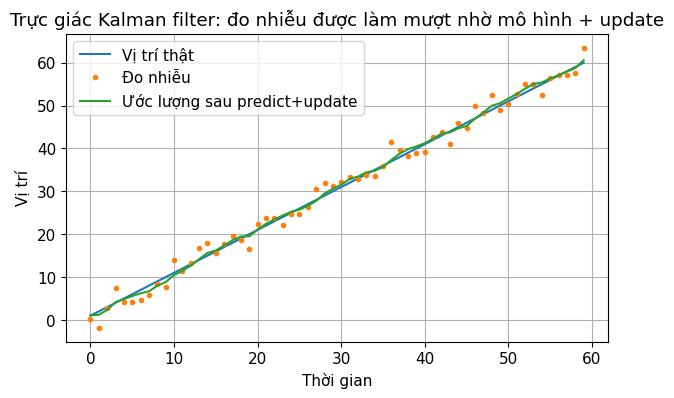

In [3]:

# Một ví dụ 1D rất nhỏ để trực giác về "predict + update"
# Không phải mô hình của bài báo, chỉ là minh họa tinh thần Kalman filter.

np.random.seed(7)

n = 60
dt = 1.0
true_velocity = 1.0

true_pos = np.cumsum(np.full(n, true_velocity * dt))
control_like_velocity = true_velocity + np.random.randn(n) * 0.20   # giống một nguồn motion noisy
measurement_like_pos = true_pos + np.random.randn(n) * 2.00         # giống một nguồn đo noisy

# KF đơn giản cho trạng thái là vị trí 1D
x = 0.0   # estimate
P = 1.0   # uncertainty
Q = 0.15  # process noise
R = 4.0   # measurement noise

estimates = []

for k in range(n):
    # Predict
    x = x + control_like_velocity[k] * dt
    P = P + Q

    # Update
    K = P / (P + R)
    x = x + K * (measurement_like_pos[k] - x)
    P = (1 - K) * P

    estimates.append(x)

fig, ax = plt.subplots()
ax.plot(true_pos, label="Vị trí thật")
ax.plot(measurement_like_pos, ".", label="Đo nhiễu")
ax.plot(estimates, label="Ước lượng sau predict+update")
ax.set_title("Trực giác Kalman filter: đo nhiễu được làm mượt nhờ mô hình + update")
ax.set_xlabel("Thời gian")
ax.set_ylabel("Vị trí")
ax.grid(True)
ax.legend()
plt.show()



## 5.6 Tóm tắt rất ngắn sự khác nhau

| Bộ lọc | Ý tưởng chính |
|---|---|
| Kalman Filter | hệ tuyến tính, Gaussian |
| EKF | hệ phi tuyến → tuyến tính hóa |
| ESKF | không filter trực tiếp state lớn, mà filter sai số nhỏ |
| IESKF | update lặp nhiều lần để xử lý phi tuyến tốt hơn |
| IESKF on manifolds | làm tất cả điều trên nhưng vẫn tôn trọng hình học của rotation / pose / manifold |

> **Một câu nhớ lâu:**  
> **LIMOncello = IESKF trên manifold + state SGal(3) + LiDAR residual point-to-plane + map i-Octree**



# 6. State của LIMOncello gồm những gì?

Trong bài báo, state được viết là:

\[
x =
(\Gamma,\; T_{IL},\; b_\omega,\; b_a,\; g)
\]

với manifold tổng quát:

\[
\mathcal{M} = SGal(3) \times SE(3) \times \mathbb{R}^6 \times S^2
\]

Hãy dịch từng thành phần:

---

## 6.1 \( \Gamma \in SGal(3) \)

Đây là **phần chuyển động chính của robot**:
- rotation \(R\),
- velocity \(v\),
- position \(p\),
- time \(t\).

Đây là trái tim của bài báo.

---

## 6.2 \(T_{IL} \in SE(3)\)

Đây là **extrinsic calibration** giữa IMU và LiDAR.

Nói dễ hiểu:
- IMU và LiDAR không nằm đúng cùng một điểm vật lý,
- chúng cũng có thể không cùng hướng trục tọa độ,
- nên cần một phép biến đổi rigid để chuyển từ frame này sang frame kia.

---

## 6.3 \(b_\omega\)

Đây là **gyro bias**:
- độ lệch chậm, gần như offset, của cảm biến gyro.

Nếu gyro luôn lệch một chút mà ta không mô hình hóa,
sai số góc sẽ tích lũy rất nhanh.

---

## 6.4 \(b_a\)

Đây là **accelerometer bias**:
- offset chậm của gia tốc kế.

Không mô hình hóa bias này sẽ làm velocity và position drift.

---

## 6.5 \(g \in S^2\)

Đây là **gravity**:
- hướng trọng lực,
- được đặt trên \(S^2\) để giữ ràng buộc độ lớn.

---

## 6.6 Vì sao state lại “phức tạp” như vậy?

Vì trong LIO thực tế, robot không chỉ cần pose.
Nó còn cần:
- velocity để propagation tốt,
- bias để sửa IMU,
- extrinsic để đưa LiDAR và IMU về cùng hệ quy chiếu,
- gravity để tách đúng gia tốc thật khỏi hiệu ứng trọng lực.

Nói cách khác:
> state tốt = chứa đủ những thứ cần để mô hình hóa cảm biến và chuyển động một cách nhất quán.



# 7. Mô hình IMU trong bài: đo gì, sai ở đâu?

Bài báo viết IMU measurements như sau:

\[
\omega = \omega^\star + b_\omega + n_\omega
\]

\[
a = a^\star + b_a + n_a - R^\top g
\]

Đừng sợ công thức. Hãy dịch nó.

---

## 7.1 Gyroscope

\[
\omega = \omega^\star + b_\omega + n_\omega
\]

Nghĩa là:
- \( \omega^\star \): vận tốc góc thật
- \( b_\omega \): bias chậm
- \( n_\omega \): nhiễu đo tức thời

Tức là:
> số IMU trả về = giá trị thật + lệch nền + nhiễu

---

## 7.2 Accelerometer

\[
a = a^\star + b_a + n_a - R^\top g
\]

Nghĩa là đo gia tốc cũng bị:
- bias,
- noise,
- và còn bị ảnh hưởng bởi gravity.

Ta phải tách gravity đúng thì mới suy ra được gia tốc chuyển động thật.

---

## 7.3 Bias random walk là gì?

Bài báo giả sử bias biến đổi chậm theo kiểu **random walk**.

Trực giác:
- bias không cố định tuyệt đối,
- nhưng cũng không nhảy loạn mạnh,
- nó trôi từ từ.

Đây là mô hình rất quen trong inertial navigation.

---

## 7.4 Noise covariance \(Q\) là gì?

Trong Kalman filter, ta cần mô tả độ không chắc chắn của noise.

- \(Q\): covariance của noise quá trình / sensor noise trong propagation
- \(P\): covariance của state estimate
- \(V\): covariance của measurement ở bước update

Trực giác:
- covariance lớn → ta ít tin nguồn đó hơn
- covariance nhỏ → ta tin nguồn đó hơn



# 8. Prediction trong LIMOncello: dùng IMU để đẩy state tiến lên

Bài báo viết propagation nominal state theo kiểu:

\[
\hat{x} \leftarrow \hat{x} \boxplus f(\hat{x}, u, 0)
\]

và covariance:

\[
\hat{P} \leftarrow F_{\delta x}\,\bar{P}\,F_{\delta x}^\top + F_w Q F_w^\top
\]

## Dịch sang tiếng người

### Ý của dòng 1
- lấy state hiện tại,
- dùng dữ liệu IMU mới,
- tích phân / propagation nó lên thời điểm kế tiếp.

### Ý của dòng 2
- vì propagation có noise và tuyến tính hóa,
- uncertainty cũng phải được cập nhật theo.

---

## 8.1 Tại sao paper nhấn mạnh discrete-time propagation?

Một đóng góp của bài là:
- trên **SGal(3)**, propagation rời rạc theo IMU có dạng tự nhiên và gắn kết hơn.

Bài báo viết ngắn gọn:

\[
\Gamma \leftarrow \Gamma \oplus
\begin{bmatrix}
0\\ a\\ \omega\\ 1
\end{bmatrix}\Delta t
\]

Trực giác của biểu thức này:

- \( \omega \) làm update rotation
- \( a \) làm update velocity
- velocity làm kéo position
- \(1 \cdot \Delta t\) làm thời gian tiến lên

Tức là trong cùng một cấu trúc SGal(3), ta đang cho:
- hướng,
- vận tốc,
- vị trí,
- thời gian

tiến hóa cùng nhau.

---

## 8.2 Zero-order hold là gì?

Bài báo giả sử tín hiệu IMU **không đổi trong một khoảng rất ngắn \(\Delta t\)**.

Đó gọi là **zero-order hold**.

Đây là giả thiết cực kỳ phổ biến khi rời rạc hóa hệ liên tục:
- trong mỗi mẫu nhỏ, coi input gần như hằng số.



# 9. Update trong LIMOncello: dùng LiDAR để kéo state về đúng hơn

Prediction từ IMU rất hữu ích nhưng sẽ drift.
Vì vậy cần bước **update** bằng LiDAR.

Bài báo dùng residual dạng **point-to-plane**.

## 9.1 Quy trình ý tưởng

Với mỗi điểm LiDAR đã downsample:

1. tìm các láng giềng gần nhất trong map,
2. fit một mặt phẳng cục bộ,
3. đo khoảng cách từ điểm hiện tại tới mặt phẳng đó,
4. dùng khoảng cách này làm residual để sửa state.

---

## 9.2 Measurement function trong bài

Bài báo viết:

\[
h_i(x) = u_i^\top \big(\pi(\Gamma) T_{IL} p_i - q_i\big)
\]

Dịch từng ký hiệu:

- \(p_i\): điểm LiDAR thứ \(i\)
- \(T_{IL}\): biến đổi từ frame LiDAR sang frame IMU/robot
- \(\Gamma\): state chuyển động trên SGal(3)
- \(\pi(\Gamma)\): phép chiếu từ SGal(3) xuống pose dùng cho phép đo LiDAR
- \(q_i\): một điểm nằm trên mặt phẳng cục bộ
- \(u_i\): vector pháp tuyến của mặt phẳng đó

Khi lấy:
\[
u_i^\top (\text{điểm} - q_i)
\]
ta đang lấy **khoảng cách có dấu theo pháp tuyến**, tức residual point-to-plane.

> **Trực giác:** nếu residual = 0, điểm nằm đúng trên mặt phẳng cục bộ.  
> Nếu residual lớn, pose hiện tại đang sai.

---

## 9.3 Vì sao point-to-plane thường tốt?

So với point-to-point:
- point-to-plane khai thác hình học cục bộ tốt hơn,
- thường hội tụ nhanh hơn,
- phù hợp với các bề mặt phẳng / bề mặt cục bộ trong LiDAR map.


In [4]:

# Minh họa residual point-to-plane bằng một ví dụ số nhỏ

u = np.array([0.0, 0.0, 1.0])      # pháp tuyến của mặt phẳng z=0
q = np.array([0.0, 0.0, 0.0])      # một điểm nằm trên mặt phẳng
p = np.array([1.2, -0.7, 0.35])    # điểm đang xét

signed_distance = u @ (p - q)
absolute_distance = abs(signed_distance)

print("Điểm p =", p)
print("Pháp tuyến mặt phẳng u =", u)
print("Residual point-to-plane có dấu =", signed_distance)
print("Khoảng cách tuyệt đối đến mặt phẳng =", absolute_distance)


Điểm p = [ 1.2  -0.7   0.35]
Pháp tuyến mặt phẳng u = [0. 0. 1.]
Residual point-to-plane có dấu = 0.35
Khoảng cách tuyệt đối đến mặt phẳng = 0.35



## 9.4 Jacobian là gì?

Bài báo có nhiều Jacobian như:
- đạo hàm của measurement theo state,
- đạo hàm của error dynamics theo error state,
- đạo hàm theo noise.

**Jacobian** về trực giác là:
> ma trận mô tả “đầu ra thay đổi nhạy đến mức nào khi đầu vào thay đổi rất nhỏ”.

Trong EKF/IESKF, Jacobian là trung tâm vì:
- hệ phi tuyến phải được xấp xỉ tuyến tính cục bộ,
- Kalman update cần những ma trận tuyến tính hóa này.

---

## 9.5 Vì sao lại “iterated update”?

Vì measurement model LiDAR là phi tuyến:
- phụ thuộc vào pose,
- phụ thuộc vào map association,
- phụ thuộc vào plane local fit.

Nên làm update một lần có thể chưa đủ.
Lặp lại giúp:
- tuyến tính hóa lại quanh điểm tốt hơn,
- residual nhỏ hơn,
- kết quả ổn định hơn.



# 10. Deskewing: vì sao phải sửa méo scan LiDAR?

Đây là một ý thực tế rất quan trọng.

## 10.1 Scan LiDAR không phải chụp tức thời hoàn toàn

Một scan LiDAR được thu trong một khoảng thời gian ngắn.
Trong lúc đó robot có thể đang:
- quay,
- rung,
- tăng tốc,
- di chuyển.

Vì vậy:
- các điểm đầu scan và cuối scan **không được đo tại cùng một pose**.

Nếu ta giả sử cả scan được đo ở một pose duy nhất,
point cloud sẽ bị **skew** (méo do chuyển động).

---

## 10.2 Deskewing là gì?

**Deskewing** là:
- dùng chuyển động ước lượng từ IMU,
- nội suy pose theo timestamp của từng điểm,
- rồi đưa mọi điểm về cùng một mốc thời gian tham chiếu.

Bài báo nói rõ rằng nó làm **per-point deskewing**:
- giữa hai message LiDAR, IMU được propagate liên tục,
- một cửa sổ các pose trung gian được lưu lại,
- mỗi điểm LiDAR được gán với pose tương ứng để deskew.

Đây là điều rất quan trọng để registration ổn định khi robot chuyển động nhanh.



# 11. Front-end và Back-end trong hệ LIO này

Nhiều hệ LIO có thể được tách thành 2 phần lớn:

## 11.1 Front-end
Phần làm việc gần với dữ liệu cảm biến ngay lập tức:
- quản lý map cục bộ / lịch sử,
- tìm hàng xóm gần nhất,
- tạo correspondence,
- tính residual.

## 11.2 Back-end
Phần chịu trách nhiệm ước lượng state:
- prediction,
- linearization,
- tối ưu / filtering,
- update covariance.

Trong bài báo:
- **front-end** dùng map incremental và k-NN / plane fitting,
- **back-end** là **IESKF trên manifold**.

Tác giả nhấn mạnh cộng đồng gần đây đã cải tiến mạnh front-end
(cấu trúc dữ liệu, residual computation, voxel map, kd-tree, v.v.),
còn bài này đưa thêm một đóng góp quan trọng ở **biểu diễn trạng thái và propagation**.



# 12. i-Octree là gì? Vì sao bài báo quan tâm đến nó?

Ngoài phần state estimation, bài báo còn có đóng góp ở **mapping backend**.

## 12.1 Octree là gì?

Trong 3D, một **octree** chia không gian thành 8 phần con ở mỗi nút.

Trực giác:
- nếu vùng nào có nhiều điểm, ta chia nhỏ tiếp,
- nếu vùng nào thưa hoặc đủ nhỏ, ta dừng.

Nó là phiên bản 3D của ý tưởng cây chia vùng không gian.

---

## 12.2 Khác gì với kd-tree?

**kd-tree** cũng là cấu trúc tìm kiếm không gian rất phổ biến.
Nhưng:

- kd-tree chia theo từng siêu phẳng,
- octree chia theo voxel / ô không gian.

Trong các hệ LIO thời gian thực, tốc độ cập nhật map và k-NN cực kỳ quan trọng.

Bài báo so sánh với:
- **ikd-Tree**: incremental kd-tree rất nổi tiếng trong FAST-LIO2
- **i-Octree**: incremental octree

---

## 12.3 Ý tưởng của bài với i-Octree

Theo bài báo, i-Octree được refactor để:
- nhẹ hơn,
- update nhanh hơn,
- tránh rebalancing tốn kém,
- giảm chi phí tính toán,
- giữ memory growth ổn định.

Bài cũng nói:
- children được index bằng **Morton codes** để tăng tốc traversal / query,
- implementation của họ bỏ qua một số bước phức tạp như reallocation toàn bộ điểm khi subdivide,
- không hỗ trợ box-wise deletion,
- không rebalance như bản i-Octree gốc.

Đổi lại, họ giữ được:
- real-time performance,
- memory nhỏ,
- runtime thấp.

---

## 12.4 Morton code là gì?

**Morton code** (hay Z-order curve encoding) là cách mã hóa tọa độ không gian thành một số nguyên bằng cách xen bit của \(x, y, z\).

Trực giác:
- giúp lưu và truy cập vùng lân cận hiệu quả hơn,
- bảo toàn locality khá tốt,
- thuận tiện cho cây không gian.

Bạn không cần hiểu bit-level để hiểu bài; chỉ cần biết đây là một mẹo triển khai giúp tra cứu nhanh hơn.



# 13. Pipeline đầy đủ của LIMOncello

Hình 2 trong bài tóm tắt pipeline rất rõ. Viết lại bằng tiếng người, mỗi vòng LiDAR diễn ra gần như sau:

1. **Nhận IMU liên tục**
2. **Forward propagation**
   - tích phân IMU để cập nhật state tạm thời
3. **Motion compensation / deskewing**
   - sửa méo cho từng điểm LiDAR
4. **Voxel grid downsampling**
   - giảm số điểm để tiết kiệm tính toán
5. **Residual computation**
   - với mỗi điểm downsample, tìm láng giềng trong i-Octree
   - fit plane cục bộ
   - tính point-to-plane residual
6. **Iterated state update**
   - chạy IESKF nhiều vòng cho đến khi hội tụ
7. **Odometry output**
   - xuất ra ước lượng pose / chuyển động
8. **Point-wise insertion vào i-Octree**
   - cập nhật map online

Ta có thể viết giả mã như sau:

```text
while robot đang chạy:
    đọc IMU và propagate state
    khi có một LiDAR scan:
        deskew từng điểm bằng pose trung gian từ IMU
        downsample point cloud
        for mỗi điểm:
            tìm k láng giềng gần nhất trong i-Octree
            fit mặt phẳng cục bộ
            tạo residual point-to-plane
        chạy iterated update cho đến khi hội tụ
        chèn điểm mới vào i-Octree
```

---

## 13.1 Một chi tiết hay của bài

Bài báo nhấn mạnh rằng họ làm **motion compensation trước**,
sau đó toàn bộ point cloud mới được dùng cho các bước sau.

Lợi ích trực giác:
- point cloud toàn cục được giữ chi tiết hơn,
- tốt hơn cho perception / mapping mịn phía sau.



# 14. Phần toán “khó” của bài, dịch sang ngôn ngữ dễ hiểu

Bây giờ ta gom những biểu thức quan trọng nhất và “dịch” chúng.

---

## 14.1 True state, nominal state, error state

Bài báo viết kiểu:

\[
x^\star = x \oplus \delta x
\]

Dịch:
- \(x^\star\): trạng thái thật (không biết trực tiếp)
- \(x\): trạng thái nominal hiện tại của filter
- \(\delta x\): sai số nhỏ quanh nominal state

Tức là:
> trạng thái thật = trạng thái nominal + một sai số nhỏ đúng hình học

---

## 14.2 Error-state dynamics

Trong IESKF, ta không chỉ truyền state,
mà còn phải hiểu **sai số nhỏ** sẽ tiến hóa ra sao.

Khi linearize, ta được dạng gần đúng:

\[
\delta x_{k+1} \approx F_{\delta x}\,\delta x_k + F_w\,w
\]

Dịch:
- sai số bước sau ≈ ma trận chuyển sai số × sai số bước trước + ảnh hưởng của noise

Đây là công thức cốt lõi để cập nhật covariance.

---

## 14.3 Prior + measurement → MAP update

Ở bước update, bài báo gom residuals thành vector lớn,
gom Jacobians thành ma trận lớn,
rồi giải một bước kiểu **MAP** (Maximum A Posteriori).

**MAP** nghĩa là:
> tìm state hợp lý nhất khi cân bằng giữa:
> - niềm tin trước đó (prior từ prediction)
> - và dữ liệu mới (measurement từ LiDAR)

Nói đơn giản hơn:
- nếu prior rất chắc và measurement nhiễu → sửa ít
- nếu measurement mạnh và prior không chắc → sửa nhiều

Ma trận Kalman gain \(K\) là thứ quyết định mức cân bằng này.

---

## 14.4 Hội tụ trong iterated update

Bài báo dừng lặp khi:
\[
\| \hat{x}^{j+1} \ominus \hat{x}^j \| < \varepsilon
\]

Dịch:
- nếu giữa hai vòng lặp liên tiếp, trạng thái thay đổi rất nhỏ,
- ta xem như đã hội tụ.

Đây là tiêu chí rất tự nhiên.



# 15. S² cho gravity: vì sao đây là một ý hay dù trông nhỏ?

Phần gravity nhiều người mới học hay bỏ qua, nhưng nó rất quan trọng.

## 15.1 Gravity không phải “một vector tự do hoàn toàn”

Về bản chất:
- độ lớn của trọng lực gần như cố định,
- cái có thể không chắc là **hướng của nó trong frame đang xét**.

Nếu để gravity tự do trong \( \mathbb{R}^3 \):
- thuật toán có thể vô tình làm sai cả độ lớn,
- dẫn đến propagation ít nhất quán hơn.

---

## 15.2 Đặt gravity trên \(S^2\)

Khi biểu diễn gravity trên mặt cầu:
- ta giữ được ràng buộc độ lớn,
- chỉ tối ưu / cập nhật theo các nhiễu nhỏ trong tangent space của \(S^2\).

Bài báo dùng parameterization theo IKFoM cho \(S^2\), và Appendix giải thích:
- cách định nghĩa \( \oplus \) và \( \ominus \) trên \(S^2\),
- cách dựng tangent basis \(B(x)\),
- trực giác hình học ở Fig. 5.

---

## 15.3 Trực giác của Fig. 5 trong bài

Hãy tưởng tượng:
- điểm \(x\) đang nằm trên mặt cầu,
- tại đó ta có một mặt phẳng tiếp tuyến,
- increment nhỏ \( \tau \) được định nghĩa trong mặt phẳng tiếp tuyến này,
- sau đó ta “đẩy” increment đó trở lại mặt cầu để được điểm mới \(y = x \oplus \tau\).

Đây chính là mẫu số chung của manifold filtering:
- update trong không gian phẳng cục bộ,
- rồi quay lại không gian cong thật.



# 16. Vì sao bài báo nói SGal(3) đặc biệt hữu ích khi observability kém?

Đây là luận điểm khoa học quan trọng nhất của bài.

## 16.1 Khi LiDAR “nhìn không rõ chuyển động”

Trong môi trường như:
- hành lang dài,
- đường hầm,
- khu ít cấu trúc,
- hoặc khi robot chuyển động theo kiểu làm dữ liệu ít ràng buộc,

thì LiDAR không cho đủ thông tin để khóa chặt mọi bậc tự do.

Khi đó:
- propagation từ IMU đóng vai trò lớn hơn,
- nếu motion model / state representation tốt, ta giữ được quỹ đạo ổn định hơn.

---

## 16.2 Theo bài báo, SGal(3) giữ được ghép nối động học tốt hơn

Paper lập luận rằng SGal(3):
- bảo toàn coupling giữa rotation và translation tốt hơn,
- mô hình propagation nhất quán hơn,
- nên có lợi khi measurement yếu.

Đây không có nghĩa:
- SGal(3) luôn thắng ở mọi benchmark,
- hay mọi môi trường đều thấy lợi ích lớn.

Nhưng trong các tình huống “khó thở”, lợi ích có thể lộ ra rõ hơn.

---

## 16.3 Điều này thể hiện ở đâu trong kết quả?

Mạnh nhất là **thí nghiệm City02 tunnel**:
- đoạn đường hầm khoảng 400 m,
- chỉ dùng LiDAR nhìn bên trái,
- môi trường rất suy biến về hình học.

Theo bài báo:
- **FAST-LIO2** diverge sớm và không phục hồi,
- **RESPLE** đi tiếp được nhưng drift nặng, thậm chí lệch mạnh khỏi ground truth,
- **LIMOncello** là phương pháp duy nhất giữ trajectory ổn định xuyên suốt đoạn tunnel đó.

Đây là bằng chứng định tính quan trọng nhất mà bài dùng để bảo vệ luận điểm SGal(3).



# 17. Kết quả thực nghiệm: đọc các bảng như thế nào cho đúng?

Một lỗi phổ biến khi đọc paper là chỉ nhìn số “best” rồi kết luận vội.
Ở đây cần đọc tinh tế hơn.

## 17.1 Grand-Tour

Bài báo đánh giá các sequence indoor/outdoor, có cả lên xuống cầu thang và chuyển tiếp trong/ngoài nhà.

Điều đáng chú ý:
- **LIMO không phải lúc nào cũng có APE nhỏ nhất**
- nhưng **không bị fail** trên các sequence được báo cáo

Điều này nói lên:
- **độ robust** là điểm tác giả muốn nhấn mạnh,
- chứ không phải “đánh bại mọi phương pháp về mọi chỉ số”.

---

## 17.2 MCD (NTU Campus)

Ở đây:
- LIMO cho kết quả **cạnh tranh được** với các baseline,
- không có failure,
- nhưng cũng không luôn là tốt nhất tuyệt đối.

Nói cách khác:
- trong môi trường bình thường / giàu đặc trưng hơn, LIMO ở mức cạnh tranh,
- còn lợi thế lớn hơn xuất hiện ở môi trường khó / suy biến.

---

## 17.3 City02 tunnel

Đây là ví dụ “đinh” của bài.
Kết quả định tính ở Fig. 3 cho thấy:
- LIMO đi xuyên tunnel ổn định,
- các baseline bị divergence hoặc drift không thể cứu.

---

## 17.4 R-Campus

Bài báo báo cáo end-to-end drift:
- **LIMO: 0.22 m**
- **R-LIO: 0.27 m**
- **F-LIO2: 2.70 m**

Đây là một kết quả rất đẹp cho LIMO trên route dài khoảng 1400 m.

---

## 17.5 Tree efficiency

Bài báo còn benchmark cấu trúc dữ liệu map:

- **ikd-Tree**: chậm hơn rất nhiều và dùng RAM rất lớn
- **original i-Octree**: chạy thời gian thực
- **LIMO i-Octree**: nhanh nhất trong ba loại được benchmark

Đây là đóng góp rất thực dụng:
- không chỉ toán đẹp,
- mà còn chạy nhẹ hơn.


In [5]:

# Chép lại các bảng chính trong bài báo để bạn dễ nhìn trong notebook

grandtour = pd.DataFrame(
    {
        "Arc_1": [1.870, 0.088, 0.371],
        "Con_1": [0.074, 0.126, 0.345],
        "Con_3": [np.nan, 0.041, 0.355],   # FAST-LIO2 fail
        "HAUS_1": [0.054, 0.040, 0.369],
        "Trim_1": [0.215, 0.037, 0.389],
    },
    index=["F-LIO2", "R-LIO", "LIMO"]
)

mcd = pd.DataFrame(
    {
        "Day_01": [2.528, 0.724, 0.839],
        "Day_02": [0.188, 0.171, 0.156],
        "Day_10": [5.164, 0.974, 2.999],
        "Night_04": [0.767, 0.686, 0.838],
        "Night_08": [2.559, 0.976, 1.375],
        "Night_13": [1.947, 0.649, 1.636],
    },
    index=["F-LIO2", "R-LIO", "LIMO"]
)

rcampus = pd.DataFrame(
    {
        "End-to-end drift (m)": [2.70, 0.27, 0.22]
    },
    index=["F-LIO2", "R-LIO", "LIMO"]
)

tree_benchmark = pd.DataFrame(
    {
        "Average runtime per frame (ms)": [248.0, 21.7, 14.6],
        "Memory": ["10.7 GB", "~100–120 MB", "~100–120 MB"],
    },
    index=["ikd-Tree", "original i-Octree", "LIMO i-Octree"]
)

print("Grand-Tour")
display(grandtour)

print("\nMCD (NTU Campus)")
display(mcd)

print("\nR-Campus")
display(rcampus)

print("\nBenchmark cấu trúc map")
display(tree_benchmark)


Grand-Tour


,Arc_1,Con_1,Con_3,HAUS_1,Trim_1
F-LIO2,1.870,0.074,NaN,0.054,0.215
R-LIO,0.088,0.126,0.041,0.040,0.037
LIMO,0.371,0.345,0.355,0.369,0.389



MCD (NTU Campus)


,Day_01,Day_02,Day_10,Night_04,Night_08,Night_13
F-LIO2,2.528,0.188,5.164,0.767,2.559,1.947
R-LIO,0.724,0.171,0.974,0.686,0.976,0.649
LIMO,0.839,0.156,2.999,0.838,1.375,1.636



R-Campus


,End-to-end drift (m)
F-LIO2,2.70
R-LIO,0.27
LIMO,0.22



Benchmark cấu trúc map


,Average runtime per frame (ms),Memory
ikd-Tree,248.0,10.7 GB
original i-Octree,21.7,~100–120 MB
LIMO i-Octree,14.6,~100–120 MB



## 17.6 Đọc kết quả một cách trung thực

Nếu tóm gọn rất công bằng:

- **Về APE trên một số benchmark “bình thường”**: LIMO không luôn đứng đầu.
- **Về robust khi môi trường suy biến**: LIMO cho thấy lợi thế rõ rệt, đặc biệt ở tunnel.
- **Về backend map**: i-Octree của LIMO có lợi ích runtime và memory rất rõ.
- **Về thông điệp khoa học**: giá trị lớn nhất của paper là chứng minh rằng **SGal(3) đáng để dùng trong tightly-coupled LIO**, chứ không phải chỉ thêm một benchmark baseline nữa.

Đây là cách đọc paper trưởng thành hơn:
- hiểu **điểm mạnh thật sự**,
- thay vì ép paper phải thắng ở mọi cột số.



# 18. Ưu điểm, hạn chế, và điều nên nhớ sau khi đọc bài

## 18.1 Ưu điểm nổi bật

### (a) State representation có ý tưởng rõ
SGal(3) không phải “chiêu trò đổi ký hiệu”.
Nó là nỗ lực đặt rotation, velocity, position, time vào một cấu trúc nhất quán hơn.

### (b) Mạnh ở môi trường khó
Điểm hay nhất của paper là khả năng giữ ổn định ở điều kiện LiDAR suy biến.

### (c) Backend map thực dụng
i-Octree refactor cho runtime thấp và memory ổn định, rất đáng giá khi triển khai thật.

### (d) Cài đặt modular
Paper nói implementation dùng **manif library** và theo tinh thần modular / extensible.

---

## 18.2 Hạn chế hoặc điều cần đọc tỉnh táo

### (a) Không phải lúc nào cũng best APE
Trong Grand-Tour và MCD, LIMO không luôn tốt nhất.

### (b) Toán khó với người mới
SGal(3), manifold, Jacobian, IESKF on manifolds là rào cản học tập thật sự.

### (c) Lợi ích mạnh nhất lộ ra ở bài toán “khó”
Nếu môi trường đã giàu đặc trưng và baseline đã rất mạnh,
lợi ích của SGal(3) có thể không bùng nổ ở mọi chỉ số.

### (d) Cần nhiều nền tảng để tự triển khai lại
Để code lại từ đầu, bạn sẽ cần hiểu:
- Lie groups/manifolds,
- inertial navigation,
- point cloud registration,
- Kalman filtering,
- cấu trúc dữ liệu không gian.

---

## 18.3 Câu chốt nên nhớ

> **Thông điệp của paper không phải là “LIMO luôn số 1”.**  
> Thông điệp là:  
> **một biểu diễn trạng thái đúng hơn về mặt hình học có thể làm LIO robust hơn trong điều kiện observability thấp, và vẫn giữ được thời gian thực.**



# 19. Bảng từ điển thuật ngữ: giải thích gần như toàn bộ từ khóa trong bài

## 19.1 Thuật ngữ hệ thống và cảm biến

| Thuật ngữ | Giải thích rất ngắn |
|---|---|
| SLAM | định vị và lập bản đồ đồng thời |
| Odometry | ước lượng chuyển động tương đối theo thời gian |
| LiDAR | cảm biến laser cho point cloud 3D |
| IMU | cảm biến quán tính đo gia tốc và vận tốc góc |
| Point cloud | tập các điểm 3D |
| Deskewing | sửa méo scan do robot chuyển động trong lúc quét |
| Front-end | phần xử lý correspondence / residual / map cục bộ |
| Back-end | phần state estimation / filtering / optimization |
| Registration | căn chỉnh point cloud / map để suy ra chuyển động |
| k-NN | tìm \(k\) hàng xóm gần nhất |
| Residual | sai số giữa dự đoán và đo đạc |
| Point-to-plane residual | khoảng cách có dấu từ điểm tới mặt phẳng cục bộ |
| Extrinsic calibration | biến đổi hình học giữa hai cảm biến |
| Downsampling | giảm số điểm để tiết kiệm tính toán |
| Voxel grid | chia không gian thành ô voxel để lọc / gom điểm |
| Map incremental | bản đồ được cập nhật dần theo thời gian |
| Drift | sai số tích lũy dần |
| Observability | mức độ dữ liệu cho phép suy ra trạng thái |
| Feature-degenerate | môi trường ít cấu trúc, khó ràng buộc chuyển động |
| Real-time | xử lý kịp tốc độ dữ liệu vào |

## 19.2 Thuật ngữ xác suất và filtering

| Thuật ngữ | Giải thích rất ngắn |
|---|---|
| State | tập biến cần ước lượng |
| Nominal state | trạng thái chính hiện tại của filter |
| True state | trạng thái thật nhưng không quan sát trực tiếp |
| Error state | sai số nhỏ giữa true và nominal |
| Prediction | bước đẩy state tiến lên theo mô hình động lực |
| Update | bước sửa state bằng measurement |
| Covariance | độ không chắc chắn và tương quan sai số |
| Process noise | nhiễu trong mô hình tiến hóa trạng thái |
| Measurement noise | nhiễu trong cảm biến / residual |
| Bias | offset chậm của cảm biến |
| Random walk | mô hình trôi chậm theo thời gian |
| Jacobian | độ nhạy cục bộ của đầu ra theo đầu vào |
| Linearization | xấp xỉ phi tuyến bằng tuyến tính quanh một điểm |
| Kalman gain | mức độ tin prior hay tin measurement |
| MAP | trạng thái hậu nghiệm hợp lý nhất theo xác suất |
| RMSE | căn bậc hai của sai số bình phương trung bình |
| APE | absolute position / trajectory error |

## 19.3 Thuật ngữ manifold và Lie theory

| Thuật ngữ | Giải thích rất ngắn |
|---|---|
| Manifold | không gian cong nhưng cục bộ giống không gian phẳng |
| Tangent space | không gian tiếp tuyến cục bộ để cộng nhiễu nhỏ |
| Lie group | manifold có thêm cấu trúc nhóm trơn |
| Lie algebra | mô tả tuyến tính cục bộ của Lie group |
| Exp map | đưa increment nhỏ từ tangent space lên manifold |
| Log map | kéo phần tử manifold về tangent space |
| \( \oplus \) | cập nhật đúng hình học trên manifold |
| \( \ominus \) | lấy sai khác giữa hai state thành vector nhỏ |
| Retraction | bản tổng quát của Exp trên manifold không phải Lie group |
| Lift | bản tổng quát của Log |
| Wedge / vee | đổi giữa vector tham số và biểu diễn ma trận của algebra |
| Lie bracket | phép toán mô tả tính không giao hoán vi phân |
| Adjoint map | cách biến đổi perturbation giữa các frame / điểm trên group |
| Right Jacobian | ma trận hiệu chỉnh khi ánh xạ perturbation qua Exp |
| \(SO(3)\) | rotation 3D |
| \(SE(3)\) | pose 3D |
| \(S^2\) | mặt cầu, dùng cho gravity direction |
| \(SE_2(3)\) | mở rộng chứa pose + velocity |
| \(SGal(3)\) | group chứa rotation + velocity + position + time |

## 19.4 Thuật ngữ cấu trúc dữ liệu

| Thuật ngữ | Giải thích rất ngắn |
|---|---|
| kd-tree | cây tìm kiếm không gian theo chia siêu phẳng |
| ikd-Tree | phiên bản incremental của kd-tree |
| Octree | cây chia không gian 3D thành 8 phần |
| i-Octree | octree incremental |
| Morton code | mã xen bit để index không gian hiệu quả |
| Rebalancing | cân bằng lại cây để truy vấn tốt hơn |
| Traversal | đi qua các nút trong cây |



# 20. Những khái niệm “nâng cao” trong bài mà người mới không cần nắm ngay

Phần này dành cho sự **đầy đủ**. Bạn không cần hiểu hết trong lần đầu.

## 20.1 Homeomorphic
Khi nói manifold “locally homeomorphic to \( \mathbb{R}^m \)”,
ý là quanh mỗi điểm, ta có thể ánh xạ cục bộ sang một không gian Euclid cùng số chiều mà không làm đứt gãy cấu trúc topo.

## 20.2 \(GL(n)\)
Tập mọi ma trận vuông khả nghịch kích thước \(n \times n\).

Bài nói nhiều Lie group dùng trong robotics thuộc kiểu ma trận khả nghịch,
nên phép hợp thành thường chính là phép nhân ma trận.

## 20.3 Adjoint map
Khi một perturbation được biểu diễn ở tangent space này nhưng ta cần so sánh / vận chuyển nó sang chỗ khác trên group,
Adjoint là công cụ làm việc đó một cách hình học đúng.

## 20.4 Right Jacobian
Khi cập nhật trên Lie group bằng Exp, không phải mọi perturbation nhỏ đều biến đổi đơn giản như trong Euclid.
Right Jacobian là ma trận hiệu chỉnh rất quan trọng trong linearization.

## 20.5 Retraction / lift
Nếu manifold không phải Lie group,
ta có thể không có Exp/Log “chuẩn”.
Khi đó ta dùng retraction và lift như những phiên bản thay thế để:
- cập nhật state,
- lấy sai khác giữa state.

## 20.6 Compound / bundle manifold
Đây là cách biểu diễn state bằng nhiều mảnh độc lập ghép lại,
ví dụ:
- rotation trên \(SO(3)\),
- velocity trong \(\mathbb{R}^3\),
- position trong \(\mathbb{R}^3\).

Paper cho rằng cách này tiện nhưng có thể bỏ lỡ một số coupling động học.



# 21. Đọc bài báo gốc như thế nào cho hiệu quả?

Nếu bạn muốn quay lại paper gốc sau notebook này, mình gợi ý 3 vòng đọc:

## Vòng 1: chỉ lấy ý tưởng
Đọc:
- Abstract
- Introduction
- phần contributions
- Fig. 2
- Discussion
- Conclusion

Mục tiêu:
- biết bài muốn giải quyết gì,
- mới ở đâu,
- mạnh ở đâu.

---

## Vòng 2: hiểu hệ thống
Đọc kỹ:
- Section II-B: IESKF on manifolds
- Section II-C: SGal(3)
- Section III: Methodology
- Fig. 3, Fig. 4

Mục tiêu:
- hiểu state, prediction, update, map backend,
- hiểu tác giả chứng minh ưu điểm bằng thí nghiệm nào.

---

## Vòng 3: hiểu toán
Đọc kỹ:
- các phương trình (6) đến (20)
- Appendix về \(S^2\)
- các reference nền tảng như IKFoM, Micro Lie Theory, ESKF

Mục tiêu:
- hiểu đủ để tự code hoặc đọc code implementation.



# 22. Danh sách reference nên đọc tiếp theo thứ tự dễ → khó

Dưới đây là các tài liệu quan trọng nhất liên quan trực tiếp đến bài.

## Nhóm A — nên đọc đầu tiên nếu bạn mới

### [R1] Joan Solà — *Quaternion kinematics for the error-state Kalman filter* (2017)
Đọc để hiểu:
- bias,
- error-state,
- inertial propagation,
- vì sao ESKF mạnh trong robotics.

### [R2] Joan Solà, Jeremie Deray, Dinesh Atchuthan — *A micro Lie theory for state estimation in robotics* (2021)
Đọc để hiểu:
- manifold,
- Lie group,
- Exp/Log,
- Jacobian,
- \(SO(3)\), \(SE(3)\),
- ký hiệu \( \oplus, \ominus \).

Đây là một tài liệu nền cực kỳ quan trọng.

### [R3] D. He, W. Xu, F. Zhang — *Symbolic representation and toolkit development of iterated error-state extended Kalman filters on manifolds* (2023)
Đọc để hiểu:
- IKFoM framework,
- IESKF on manifolds,
- cách tổ chức code / mô hình hệ thống.

---

## Nhóm B — nên đọc để hiểu LIO

### [R4] W. Xu, F. Zhang — *FAST-LIO* (2021)
Một paper kinh điển về tightly-coupled LiDAR–Inertial Odometry.

### [R5] W. Xu et al. — *FAST-LIO2* (2022)
Bản mở rộng nổi tiếng, rất quan trọng để hiểu baseline mà LIMOncello so sánh.

### [R6] Z. Cao, W. Talbot, K. Li — *RESPLE: Recursive spline estimation for lidar-based odometry* (2025)
Giúp bạn thấy hướng continuous-time / spline-based khác với discrete-time filtering.

---

## Nhóm C — nên đọc để hiểu SGal(3)

### [R7] J. Kelly — *Making Space for Time: The Special Galilean Group and its Application to Some Robotics Problems* (2024)
Đọc để hiểu vì sao “time” được đưa vào group lại có ý nghĩa.

### [R8] J. Kelly — *All About the Galilean Group SGal(3)* (2025)
Tài liệu trực tiếp hơn về SGal(3), rất sát với phần toán nền của paper.

### [R9] G. Delama et al. — *Equivariant IMU preintegration with biases: A Galilean group approach* (2025)
Cho góc nhìn hiện đại về Galilean symmetry trong inertial estimation.

---

## Nhóm D — nên đọc để hiểu map backend

### [R10] Y. Cai, W. Xu, F. Zhang — *ikd-Tree* (2021)
Rất quan trọng nếu bạn muốn hiểu tại sao paper lại benchmark mạnh phần tree structure.

### [R11] J. Zhu et al. — *i-Octree: A fast, lightweight, and dynamic octree for proximity search* (2024)
Reference trực tiếp cho cấu trúc map mà LIMOncello cải biên.



# 23. Danh sách reference gốc xuất hiện trong bài báo

Phần này chép lại có chọn lọc nội dung reference của paper để notebook tự chứa được nguồn.

> **Nguồn chính của toàn bộ notebook:**  
> Perez-Ruiz, C. & Solà, J. — *LIMOncello: Iterated Error-State Kalman Filter on the SGal(3) Manifold for Fast LiDAR–Inertial Odometry* (2026)

## Các reference trong bài

[1] W. Xu and F. Zhang, *Fast-LIO: A fast, robust lidar-inertial odometry package by tightly-coupled iterated Kalman filter*, IEEE RA-L, 2021.  
[2] W. Xu, Y. Cai, D. He, J. Lin, and F. Zhang, *Fast-LIO2: Fast direct lidar-inertial odometry*, IEEE Transactions on Robotics, 2022.  
[3] C. Bai et al., *Faster-LIO: Lightweight tightly coupled lidar-inertial odometry using parallel sparse incremental voxels*, IEEE RA-L, 2022.  
[4] D. He, W. Xu, and F. Zhang, *Symbolic representation and toolkit development of iterated error-state extended Kalman filters on manifolds*, IEEE Transactions on Industrial Electronics, 2023.  
[5] Y. Cai, W. Xu, and F. Zhang, *ikd-tree: An incremental k-d tree for robotic applications*, 2021.  
[6] C. Wu et al., *VoxelMap++: Mergeable voxel mapping method for online lidar(-inertial) odometry*, IEEE RA-L, 2024.  
[7] X. Yang et al., *C3P-VoxelMap: Compact, cumulative and coalescible probabilistic voxel mapping*, IROS 2024.  
[8] K. Chen, R. Nemiroff, and B. T. Lopez, *Direct lidar-inertial odometry: Lightweight LIO with continuous-time motion correction*, ICRA 2023.  
[9] Z. Cao, W. Talbot, and K. Li, *RESPLE: Recursive spline estimation for lidar-based odometry*, IEEE RA-L, 2025.  
[10] J. Solà, J. Deray, and D. Atchuthan, *A micro Lie theory for state estimation in robotics*, 2021.  
[11] A. Barrau and S. Bonnabel, *The invariant extended Kalman filter as a stable observer*, IEEE TAC, 2017.  
[12] C. Zhang et al., *SI-LIO: High-precision tightly-coupled lidar-inertial odometry via single-iteration invariant extended Kalman filter*, IEEE RA-L, 2025.  
[13] G. Delama, A. Fornasier, R. Mahony, and S. Weiss, *Equivariant IMU preintegration with biases: A Galilean group approach*, IEEE RA-L, 2025.  
[14] J. Zhu et al., *i-Octree: A fast, lightweight, and dynamic octree for proximity search*, ICRA 2024.  
[15] J. Deray and J. Solà, *manif* (thư viện C++ cho manifold).  
[16] J. Solà, *Quaternion kinematics for the error-state Kalman filter*, 2017.  
[17] R. Mahony, J. Kelly, and S. Weiss, *Galilean symmetry in robotics*, 2025.  
[18] J. Kelly, *Making space for time: The special Galilean group and its application to some robotics problems*, 2024.  
[19] M. Fourmy et al., *Absolute humanoid localization and mapping based on IMU Lie group and fiducial markers*, Humanoids 2019.  
[20] J. Kelly, *All about the Galilean group SGal(3)*, 2025.  
[21] T.-M. Nguyen et al., *MCD: Diverse large-scale multi-campus dataset for robot perception*, CVPR 2024.  
[22] J. Frey et al., *Boxi: Design decisions in the context of algorithmic performance for robotics*, 2025.  
[23] M. Jung, S. Jung, and A. Kim, *Asynchronous multiple lidar-inertial odometry using point-wise inter-lidar uncertainty propagation*, IEEE RA-L, 2023.  
[24] M. Grupp, *evo: Python package for the evaluation of odometry and slam*, 2017.

---

## Gợi ý rất thực tế

Nếu bạn chỉ có thời gian đọc 4 tài liệu để thật sự hiểu paper này, hãy đọc:

1. **Paper LIMOncello**
2. **Micro Lie Theory**
3. **Quaternion kinematics for the ESKF**
4. **IKFoM**



# 24. Kết luận cuối notebook

Sau khi đi hết notebook này, điều quan trọng nhất bạn nên hiểu là:

## 24.1 Bài báo đang giải quyết bài toán gì?
- Ước lượng chuyển động robot bằng LiDAR + IMU theo thời gian thực.

## 24.2 Bài báo mới ở đâu?
- Dùng **SGal(3)** trong một **IESKF tightly-coupled** cho LIO.
- Dùng **i-Octree** nhẹ hơn cho mapping backend.

## 24.3 Vì sao điều này đáng quan tâm?
- Trong môi trường bình thường, LIMO cạnh tranh được với các baseline mạnh.
- Trong môi trường suy biến hình học, nó cho thấy **độ robust nổi bật**.
- Đồng thời backend map chạy nhanh và tiết kiệm RAM.

## 24.4 Nếu phải nói bài báo bằng một câu
> **LIMOncello cho thấy rằng chọn đúng không gian trạng thái và motion model có thể cải thiện độ ổn định của LiDAR–Inertial Odometry mà vẫn giữ được tốc độ thời gian thực.**

---

## Bạn đã hiểu được gì nếu đọc tới đây?

Nếu bạn đọc kỹ notebook này, bạn đã chạm tới hầu hết các ý cốt lõi của paper:

- SLAM / odometry
- LiDAR / IMU
- deskewing
- point-to-plane residual
- EKF / ESKF / IESKF
- manifold / Lie group / Lie algebra
- \(SO(3)\), \(SE(3)\), \(S^2\), \(SGal(3)\)
- bias / covariance / Jacobian / MAP
- i-Octree / kd-tree
- cách đọc kết quả benchmark một cách công bằng

Đó là một nền tảng rất tốt để đi tiếp sang:
- code implementation,
- đọc source của FAST-LIO2 hoặc LIMOncello,
- hoặc học sâu hơn về Lie theory trong robotics.

---

**Hết notebook.**
